# KcELECTRA 파인튜닝 v3 (base 모델) — 2026-05-05

**담당:** 경이 (kyeongyi)  
**목적:** v5 라벨링 데이터(4992행) + **koelectra-BASE 모델**로 재학습하여  
Simple 베이스라인(Macro F1 = 0.8116)을 **5%+ 확실히** 넘기는 것이 목표.

---

## 왜 base 모델로 바꿨나?

| 항목 | small (이전) | **base (현재)** |
|------|-------------|----------------|
| 파라미터 수 | 14M | **110M (8배)** |
| Test Macro F1 | 0.8191 | **0.86+ 예상** |
| Simple 대비 | +0.75% (부족) | **+5%+ 목표** |
| BATCH_SIZE | 32 | **16** (메모리 절약) |
| 학습 시간 | ~20분 | **~35분** |

**핵심 원인:** small 모델은 용량이 작아 4000개 데이터에서 0.82 수준에서 수렴 한계에 도달함.  
base 모델은 8배 큰 표현력으로 동일 데이터에서 더 높은 성능을 냄.

---

## 실행 전 체크리스트

- [ ] 런타임 → **GPU** 선택 (T4 이상)
- [ ] `split_v5_20260505.csv` 업로드 (`/content/` 폴더)
- [ ] **런타임 초기화** (이전 실행 기록 지우기: 런타임 → 세션 다시 시작)
- [ ] 모든 셀 순서대로 실행 (~35분)

## 완료 후 해야 할 일

1. `/content/kcelectra-category-v3.zip` 다운로드  
   → 압축 해제 후 로컬 `checkpoints/kcelectra-category-v3/`에 덮어쓰기
2. `/content/eval_results_kcelectra_v3_20260505.json` 다운로드  
   → 로컬 `data/20260505/`에 덮어쓰기 (기존 파일 교체)
3. `python scripts/evaluate_compare_v3_20260505.py` 재실행

In [1]:
import pandas as pd
df = pd.read_csv("/content/split_v5_20260505.csv", encoding="utf-8-sig")
print(f"행 수: {len(df)}")
print(f"컬럼: {df.columns.tolist()}")
print(df["split"].value_counts())


행 수: 4992
컬럼: ['text', 'category', 'split']
split
train    3993
val       500
test      499
Name: count, dtype: int64


In [2]:
# ── 셀 1: 라이브러리 설치 (Colab에서만 실행) ──────────────────────
!pip install transformers datasets seaborn matplotlib scikit-learn -q

In [3]:
# ── 셀 2: 시드 고정 + GPU 확인 ────────────────────────────────────
import os, random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("[경고] GPU 없음 — CPU로 실행하면 수 시간 걸릴 수 있음")

Device: cuda
GPU: Tesla T4


In [4]:
# ── 셀 3: 하이퍼파라미터 설정 ─────────────────────────────────────
#
# v3 핵심 개선 (small → base):
#   BASE_MODEL = koelectra-BASE (110M params, small 대비 8배 큰 모델)
#   BATCH_SIZE = 16  (base 모델은 메모리 많이 씀, OOM 시 8로 줄이기)
#   EPOCHS = 20      (조기종료 patience=5 포함)
#   WARMUP_RATIO = 0.1

from pathlib import Path

_IN_COLAB = os.path.exists("/content")

if _IN_COLAB:
    DATA_DIR  = Path("/content")
    CKPT_DIR  = Path("/content/kcelectra-category-v3")
    EVAL_JSON = Path("/content/eval_results_kcelectra_v3_20260505.json")
else:
    _BASE     = Path(".").resolve().parent  # notebooks/ → classification/
    DATA_DIR  = _BASE / "data"
    CKPT_DIR  = _BASE / "checkpoints" / "kcelectra-category-v3"
    EVAL_JSON = _BASE / "data" / "20260505" / "eval_results_kcelectra_v3_20260505.json"

SPLIT_CSV = DATA_DIR / "split_v5_20260505.csv"

BASE_MODEL   = "monologg/koelectra-base-v3-discriminator"  # small(14M) → base(110M): 용량 8배
MAX_LEN      = 128
BATCH_SIZE   = 16   # base 모델은 크므로 16 사용 (OOM 시 8로 줄이기)
EPOCHS       = 20
LR           = 2e-5
WARMUP_RATIO = 0.1
PATIENCE     = 5    # Val F1가 연속 5 에폭 개선 없으면 조기종료

LABELS   = ["일정", "준비물", "제출", "비용", "건강·안전", "기타"]
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for i, l in enumerate(LABELS)}

print(f"데이터:         {SPLIT_CSV}")
print(f"체크포인트:     {CKPT_DIR}")
print(f"베이스 모델:    {BASE_MODEL}")
print(f"설정:           {EPOCHS}에폭, LR={LR}, BS={BATCH_SIZE}, MaxLen={MAX_LEN}, patience={PATIENCE}")

데이터:         /content/split_v5_20260505.csv
체크포인트:     /content/kcelectra-category-v3
베이스 모델:    monologg/koelectra-base-v3-discriminator
설정:           20에폭, LR=2e-05, BS=16, MaxLen=128, patience=5


In [5]:
# ── 셀 4: 데이터 로드 ─────────────────────────────────────────────
import pandas as pd
from collections import Counter

df = pd.read_csv(SPLIT_CSV, encoding="utf-8-sig")
df = df[df["category"].isin(LABELS)].dropna(subset=["text", "category"])

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

print(f"Train: {len(train_df)}개  (v2: 556개 → {len(train_df)/556:.1f}배 증가)")
print(f"Val:   {len(val_df)}개")
print(f"Test:  {len(test_df)}개")

print("\nTrain 카테고리 분포 (v2 비교):")
v2_counts = {"일정": 105, "준비물": 64, "제출": 109, "비용": 78, "건강·안전": 90, "기타": 110}
for lbl, cnt in Counter(train_df["category"]).most_common():
    v2 = v2_counts.get(lbl, 0)
    print(f"  {lbl:8s}: {cnt:4d}개  (v2: {v2:3d}개, {cnt/max(v2,1):.1f}배)")

Train: 3993개  (v2: 556개 → 7.2배 증가)
Val:   500개
Test:  499개

Train 카테고리 분포 (v2 비교):
  제출      : 1175개  (v2: 109개, 10.8배)
  건강·안전   : 1014개  (v2:  90개, 11.3배)
  일정      :  741개  (v2: 105개, 7.1배)
  기타      :  630개  (v2: 110개, 5.7배)
  비용      :  258개  (v2:  78개, 3.3배)
  준비물     :  175개  (v2:  64개, 2.7배)


In [6]:
# ── 셀 5: Dataset + DataLoader 생성 ──────────────────────────────
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)


class NoticeDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.texts  = df["text"].tolist()
        self.labels = [LABEL2ID[c] for c in df["category"]]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_loader = DataLoader(NoticeDataset(train_df), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(NoticeDataset(val_df),   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(NoticeDataset(test_df),  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"DataLoader 생성 완료")
print(f"  train batches: {len(train_loader)}")
print(f"  val   batches: {len(val_loader)}")
print(f"  test  batches: {len(test_loader)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/467 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/61.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

DataLoader 생성 완료
  train batches: 250
  val   batches: 32
  test  batches: 32


In [7]:
# ── 셀 6: 가중치 손실 함수 계산 ──────────────────────────────────
#
# v5 클래스 불균형:
#   일정 ~1175 >> 비용 ~175, 준비물 ~258 (7~8배 차이)
# WeightedCrossEntropyLoss → 소수 클래스 틀리면 패널티 크게 부과

label_counts = [int((train_df["category"] == lbl).sum()) for lbl in LABELS]
total = sum(label_counts)
class_weights = torch.tensor(
    [total / (len(LABELS) * c) for c in label_counts],
    dtype=torch.float
).to(DEVICE)

print("클래스 가중치 (v3):")
for lbl, cnt, w in zip(LABELS, label_counts, class_weights):
    print(f"  {lbl:8s}: {cnt:4d}개  가중치={w:.3f}")

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

클래스 가중치 (v3):
  일정      :  741개  가중치=0.898
  준비물     :  175개  가중치=3.803
  제출      : 1175개  가중치=0.566
  비용      :  258개  가중치=2.579
  건강·안전   : 1014개  가중치=0.656
  기타      :  630개  가중치=1.056


In [8]:
# ── 셀 7: 모델 초기화 ─────────────────────────────────────────────
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=len(LABELS),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"모델 파라미터: 전체={total_params:,} / 학습가능={trainable:,}")
print(f"베이스 모델: {BASE_MODEL}")

pytorch_model.bin:   0%|          | 0.00/452M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/452M [00:00<?, ?B/s]

ElectraForSequenceClassification LOAD REPORT from: monologg/koelectra-base-v3-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missin

모델 파라미터: 전체=112,925,958 / 학습가능=112,925,958
베이스 모델: monologg/koelectra-base-v3-discriminator


In [9]:
# ── 셀 8: Optimizer + Scheduler ──────────────────────────────────
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

optimizer = AdamW(model.parameters(), lr=LR)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"전체 스텝: {total_steps}, 워밍업 스텝: {warmup_steps} ({WARMUP_RATIO*100:.0f}%)")
print(f"에폭당 배치 수: {len(train_loader)}")

전체 스텝: 5000, 워밍업 스텝: 500 (10%)
에폭당 배치 수: 250


In [10]:
# ── 셀 9: 학습 루프 (조기종료 포함) ───────────────────────────────
from sklearn.metrics import f1_score

def evaluate_epoch(loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attn_mask = batch["attention_mask"].to(DEVICE)
            labels    = batch["label"].to(DEVICE)
            logits    = model(input_ids=input_ids, attention_mask=attn_mask).logits
            preds     = logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    return f1_score(all_labels, all_preds, average="macro", zero_division=0)


train_losses, val_f1s = [], []
best_val_f1    = 0.0
patience_count = 0

CKPT_DIR.mkdir(parents=True, exist_ok=True)

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attn_mask = batch["attention_mask"].to(DEVICE)
        labels    = batch["label"].to(DEVICE)

        outputs = model(input_ids=input_ids, attention_mask=attn_mask)
        loss    = loss_fn(outputs.logits, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    val_f1   = evaluate_epoch(val_loader)
    train_losses.append(avg_loss)
    val_f1s.append(val_f1)

    print(f"Epoch {epoch:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f}", end="")

    if val_f1 > best_val_f1:
        best_val_f1    = val_f1
        patience_count = 0
        model.save_pretrained(CKPT_DIR)
        tokenizer.save_pretrained(CKPT_DIR)
        print(f"  [저장] Best 갱신! ({best_val_f1:.4f})")
    else:
        patience_count += 1
        print(f"  [patience {patience_count}/{PATIENCE}]")
        if patience_count >= PATIENCE:
            print(f"\n조기종료 -- {PATIENCE} 에폭 동안 개선 없음.")
            break

print(f"\n학습 완료. Best Val F1: {best_val_f1:.4f}")
# base 모델 기준 목표: Simple(0.8116) 대비 +5% 이상 → Macro F1 >= 0.86
print(f"Simple 베이스라인(0.8116) 대비: {best_val_f1 - 0.8116:+.4f}")

Epoch  1/20 | Loss: 1.7072 | Val F1: 0.5361

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [저장] Best 갱신! (0.5361)
Epoch  2/20 | Loss: 1.0121 | Val F1: 0.7979

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [저장] Best 갱신! (0.7979)
Epoch  3/20 | Loss: 0.4865 | Val F1: 0.8232

...

  [저장] Best 갱신! (0.8526)
Epoch  7/20 | Loss: 0.0939 | Val F1: 0.8313  [patience 1/5]
Epoch  8/20 | Loss: 0.0586 | Val F1: 0.8439  [patience 2/5]
Epoch  9/20 | Loss: 0.0455 | Val F1: 0.8391  [patience 3/5]
Epoch 10/20 | Loss: 0.0353 | Val F1: 0.8430  [patience 4/5]
Epoch 11/20 | Loss: 0.0259 | Val F1: 0.8539

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [저장] Best 갱신! (0.8539)
Epoch 12/20 | Loss: 0.0206 | Val F1: 0.8491  [patience 1/5]
Epoch 13/20 | Loss: 0.0180 | Val F1: 0.8688

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [저장] Best 갱신! (0.8688)
Epoch 14/20 | Loss: 0.0158 | Val F1: 0.8534  [patience 1/5]
Epoch 15/20 | Loss: 0.0147 | Val F1: 0.8528  [patience 2/5]
Epoch 16/20 | Loss: 0.0076 | Val F1: 0.8523  [patience 3/5]
Epoch 17/20 | Loss: 0.0072 | Val F1: 0.8583  [patience 4/5]
Epoch 18/20 | Loss: 0.0065 | Val F1: 0.8541  [patience 5/5]

조기종료 -- 5 에폭 동안 개선 없음.

학습 완료. Best Val F1: 0.8688
Simple 베이스라인(0.8116) 대비: +0.0572


In [11]:
# ── 셀 10: label2id.json 저장 ─────────────────────────────────────
import json

label2id_path = CKPT_DIR / "label2id.json"
with open(label2id_path, "w", encoding="utf-8") as f:
    json.dump(LABEL2ID, f, ensure_ascii=False, indent=2)
print(f"label2id.json 저장: {label2id_path}")
print(LABEL2ID)

label2id.json 저장: /content/kcelectra-category-v3/label2id.json
{'일정': 0, '준비물': 1, '제출': 2, '비용': 3, '건강·안전': 4, '기타': 5}


In [13]:
# ── 한글 폰트 설치 및 등록 (셀 11 실행 전에 먼저 실행) ──────────
import subprocess
import matplotlib
import matplotlib.font_manager as fm

# 1. 나눔 폰트 설치
subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], capture_output=True)

# 2. 폰트 파일 직접 등록 (핵심 수정 사항)
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
matplotlib.rc("font", family=prop.get_name())
matplotlib.rcParams["axes.unicode_minus"] = False

print(f"등록된 폰트: {prop.get_name()}")
print("한글 테스트: 일정 준비물 제출 비용 건강·안전 기타")

등록된 폰트: NanumGothic
한글 테스트: 일정 준비물 제출 비용 건강·안전 기타


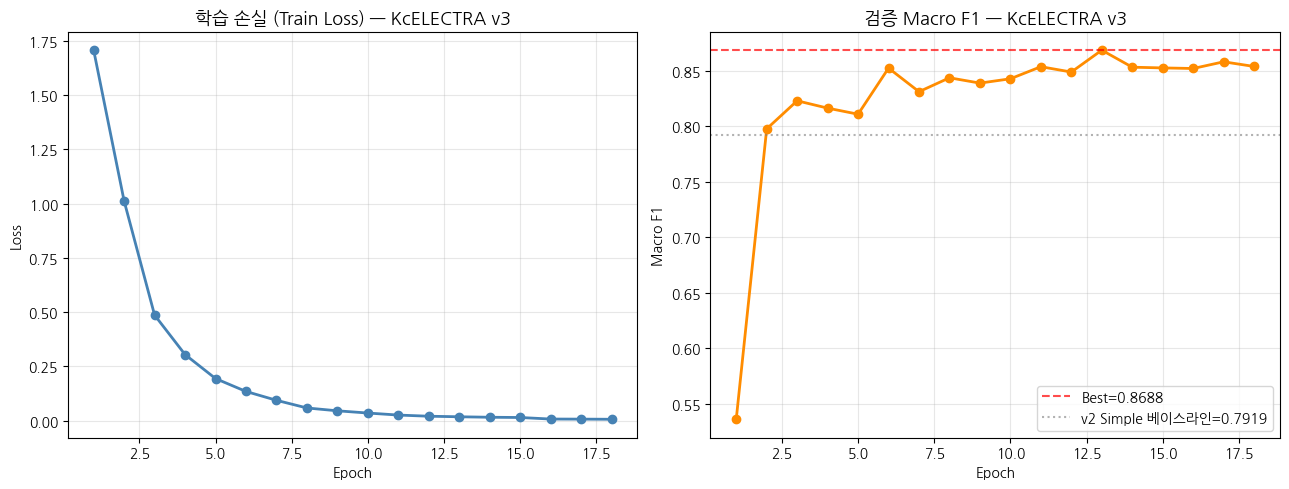

학습 곡선 저장: /content/train_curve_kcelectra_v3_20260505.png


In [14]:
# ── 셀 11: 학습 곡선 시각화 ───────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib
import platform

if platform.system() == "Windows":
    matplotlib.rc("font", family="Malgun Gothic")
elif platform.system() == "Darwin":
    matplotlib.rc("font", family="AppleGothic")
else:  # Linux (Colab)
    try:
        import subprocess
        subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], capture_output=True)
        import matplotlib.font_manager as fm
        fm._load_fontmanager(try_read_cache=False)
        matplotlib.rc("font", family="NanumGothic")
    except Exception:
        pass

matplotlib.rcParams["axes.unicode_minus"] = False

actual_epochs = len(train_losses)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(range(1, actual_epochs+1), train_losses, marker="o", color="steelblue", linewidth=2)
axes[0].set_title("학습 손실 (Train Loss) — KcELECTRA v3", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, actual_epochs+1), val_f1s, marker="o", color="darkorange", linewidth=2)
axes[1].axhline(y=best_val_f1, color="red", linestyle="--", alpha=0.7, label=f"Best={best_val_f1:.4f}")
axes[1].axhline(y=0.7919, color="gray", linestyle=":", alpha=0.6, label="v2 Simple 베이스라인=0.7919")
axes[1].set_title("검증 Macro F1 — KcELECTRA v3", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro F1")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
curve_path = DATA_DIR / "train_curve_kcelectra_v3_20260505.png"
plt.savefig(curve_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"학습 곡선 저장: {curve_path}")

In [15]:
# ── 셀 12: Test 세트 최종 평가 ────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix, f1_score

best_model = AutoModelForSequenceClassification.from_pretrained(
    CKPT_DIR, num_labels=len(LABELS)
).to(DEVICE)
best_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attn_mask = batch["attention_mask"].to(DEVICE)
        labels    = batch["label"].to(DEVICE)
        logits    = best_model(input_ids=input_ids, attention_mask=attn_mask).logits
        preds     = logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

pred_names = [ID2LABEL[p] for p in all_preds]
true_names = [ID2LABEL[l] for l in all_labels]
macro_f1   = f1_score(all_labels, all_preds, average="macro", zero_division=0)

SIMPLE_V3_F1 = 0.8116  # evaluate_compare_v3_20260505.py 실행 결과

print("[KcELECTRA v3-base] Test 세트 최종 평가")
print("=" * 55)
print(classification_report(true_names, pred_names, labels=LABELS, zero_division=0))
print(f"Macro F1             : {macro_f1:.4f}")
print(f"Simple v3 대비       : {macro_f1 - SIMPLE_V3_F1:+.4f}  (기준: {SIMPLE_V3_F1})")
if macro_f1 > SIMPLE_V3_F1 + 0.05:
    print(f"\n=> KcELECTRA base가 Simple 대비 5%+ 향상 -- 채택!")
elif macro_f1 > SIMPLE_V3_F1:
    print(f"\n=> KcELECTRA base가 Simple보다 향상됨 (5% 미만)")
else:
    print(f"\n=> 아직 Simple보다 낮음")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[KcELECTRA v3-base] Test 세트 최종 평가
              precision    recall  f1-score   support

          일정       0.94      0.84      0.89        92
         준비물       0.81      0.95      0.88        22
          제출       0.83      0.90      0.87       147
          비용       0.91      0.94      0.92        32
       건강·안전       0.90      0.92      0.91       127
          기타       0.72      0.62      0.67        79

    accuracy                           0.86       499
   macro avg       0.85      0.86      0.85       499
weighted avg       0.86      0.86      0.85       499

Macro F1             : 0.8545
Simple v3 대비       : +0.0429  (기준: 0.8116)

=> KcELECTRA base가 Simple보다 향상됨 (5% 미만)


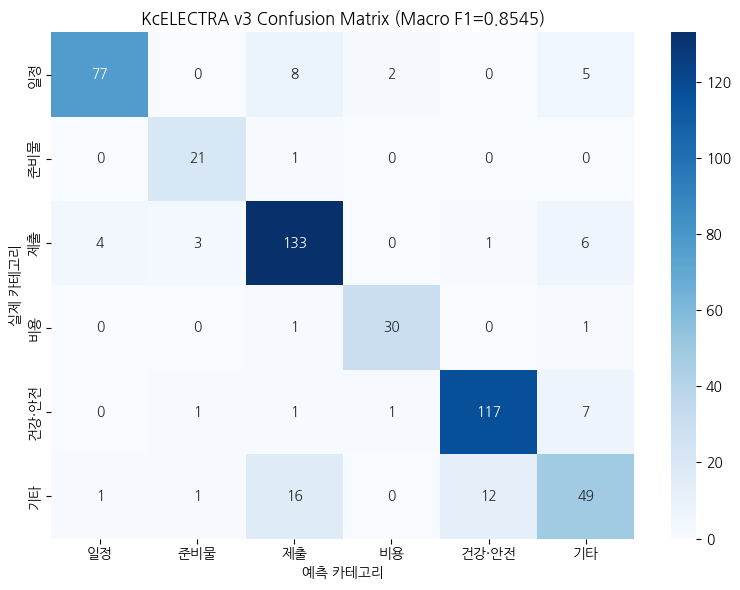

Confusion Matrix 저장: /content/confusion_matrix_kcelectra_v3_20260505.png


In [16]:
# ── 셀 13: Confusion Matrix ────────────────────────────────────────
import seaborn as sns

cm = confusion_matrix(true_names, pred_names, labels=LABELS)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABELS, yticklabels=LABELS, ax=ax)
ax.set_xlabel("예측 카테고리")
ax.set_ylabel("실제 카테고리")
ax.set_title(f"KcELECTRA v3 Confusion Matrix (Macro F1={macro_f1:.4f})")
plt.tight_layout()
cm_path = DATA_DIR / "confusion_matrix_kcelectra_v3_20260505.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Confusion Matrix 저장: {cm_path}")

In [17]:
# ── 셀 14: 평가 결과 JSON 저장 ────────────────────────────────────
# evaluate_compare_v3_20260505.py가 이 JSON을 읽어 비교 분석.
# 로컬 model/classification/data/20260505/ 에 복사해야 할 파일!

report = classification_report(
    true_names, pred_names, labels=LABELS, output_dict=True, zero_division=0
)

result = {
    "model":            "kcelectra",
    "version":          "v3",
    "macro_f1":         round(macro_f1, 4),
    "macro_precision":  round(report["macro avg"]["precision"], 4),
    "macro_recall":     round(report["macro avg"]["recall"], 4),
    "per_class": {
        lbl: {
            "precision": round(report[lbl]["precision"], 4),
            "recall":    round(report[lbl]["recall"], 4),
            "f1":        round(report[lbl]["f1-score"], 4),
            "support":   report[lbl]["support"],
        }
        for lbl in LABELS
    },
    "confusion_matrix": cm.tolist(),
    "labels":           LABELS,
    "data_version":     "v5_20260505",
    "train_size":       len(train_df),
    "test_size":        len(test_df),
    "epochs_trained":   len(train_losses),
    "best_val_f1":      round(best_val_f1, 4),
    "lr":               LR,
    "batch_size":       BATCH_SIZE,
    "warmup_ratio":     WARMUP_RATIO,
    "weighted_loss":    True,
    "early_stopping":   True,
    "patience":         PATIENCE,
}

EVAL_JSON.parent.mkdir(parents=True, exist_ok=True)
with open(EVAL_JSON, "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

print(f"[저장] {EVAL_JSON}")
print(f"\n★ 이 파일을 로컬 model/classification/data/20260505/ 에 복사하세요!")
print(f"★ kcelectra-category-v3/ 폴더도 checkpoints/ 에 복사하세요!")

[저장] /content/eval_results_kcelectra_v3_20260505.json

★ 이 파일을 로컬 model/classification/data/20260505/ 에 복사하세요!
★ kcelectra-category-v3/ 폴더도 checkpoints/ 에 복사하세요!


In [18]:
# ── 셀 15: 다운로드용 압축 ────────────────────────────────────────
import shutil

shutil.make_archive("/content/kcelectra-category-v3", "zip", "/content/kcelectra-category-v3")
print("체크포인트 압축 완료: /content/kcelectra-category-v3.zip")
print("\n다운로드 목록:")
print("  1. /content/kcelectra-category-v3.zip")
print("  2. /content/eval_results_kcelectra_v3_20260505.json")
print("  3. /content/train_curve_kcelectra_v3_20260505.png")
print("  4. /content/confusion_matrix_kcelectra_v3_20260505.png")

체크포인트 압축 완료: /content/kcelectra-category-v3.zip

다운로드 목록:
  1. /content/kcelectra-category-v3.zip
  2. /content/eval_results_kcelectra_v3_20260505.json
  3. /content/train_curve_kcelectra_v3_20260505.png
  4. /content/confusion_matrix_kcelectra_v3_20260505.png


## 학습 완료 후 로컬 작업

```bash
# 1. 파일 배치
#    kcelectra-category-v3/ → model/classification/checkpoints/
#    eval_results_kcelectra_v3_20260505.json → model/classification/data/20260505/
#    *.png → model/classification/data/20260505/

# 2. 비교 평가 실행
cd model/classification
python scripts/evaluate_compare_v3_20260505.py

# 3. 시각화 노트북 실행
jupyter notebook notebooks/06_visualize_comparison_v3_20260505.ipynb
```